<a href="https://colab.research.google.com/github/aryaraut13/100-days-of-aiml/blob/main/phase1-foundations/day15_modelevaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                     Accuracy      F1  ROC-AUC  CV Mean
Model                                                  
Logistic Regression    0.8525  0.8571   0.9267   0.8180
Decision Tree          0.8525  0.8525   0.8432   0.7605
Random Forest          0.8361  0.8438   0.9224   0.8058


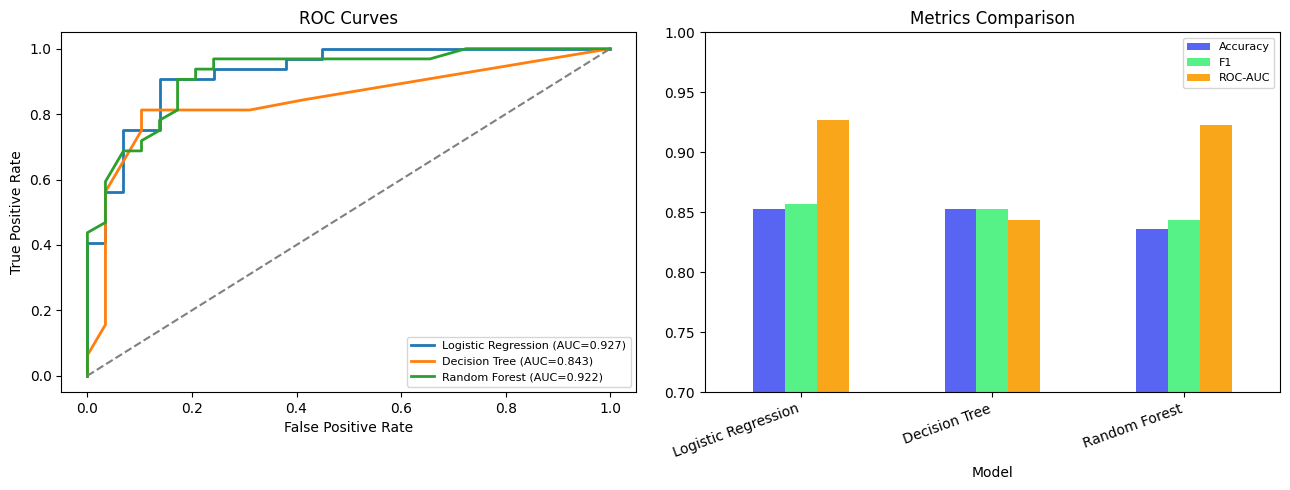

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, f1_score)
import seaborn as sns

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df  = pd.read_csv(url)

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results = []
for name, m in models.items():
    m.fit(X_train_s, y_train)
    y_pred  = m.predict(X_test_s)
    y_proba = m.predict_proba(X_test_s)[:, 1]
    acc     = np.mean(y_pred == y_test)
    f1      = f1_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)
    cv      = cross_val_score(m, X_train_s, y_train, cv=5).mean()
    results.append({"Model": name, "Accuracy": acc, "F1": f1, "ROC-AUC": auc, "CV Mean": cv})
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1],"--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(fontsize=8)

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(4).to_string())

results_df[["Accuracy","F1","ROC-AUC"]].plot(kind="bar", ax=axes[1],
                                               color=["#5865F2","#57F287","#FAA61A"],
                                               edgecolor="none")
axes[1].set_title("Metrics Comparison")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].set_ylim(0.7, 1.0)
axes[1].legend(fontsize=8)

plt.tight_layout()

plt.show()